In [5]:
pip install xgboost 


  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)


In [1]:
import pyreadr
import pandas as pd

# Load the RDS files
train_result = pyreadr.read_r("train.rds")
test_result = pyreadr.read_r("test.rds")

# Extract the dataframes (they are stored as a dict)
train_df = train_result[None]
test_df = test_result[None]

# Basic exploration
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns)

print("\nFirst few rows of train data:")
print(train_df.head())

# Check for missing values
print("\nMissing values in train:")
print(train_df.isnull().sum())

# Check class balance if there is a label column
if 'cell_type' in train_df.columns:
    print("\nCell type distribution:")
    print(train_df['cell_type'].value_counts())


Train shape: (31011, 10002)
Test shape: (20216, 10001)

Train columns:
Index(['SampleID', 'CellType', 'IGLV3-19', 'IGHV4-34', 'IGKC', 'IGHA1',
       'IGLC3', 'S100A2', 'SCGB3A1', 'IGHG1',
       ...
       'AC092794.2', 'AC016722.3', 'LINC01119', 'LINC01291', 'AC010132.4',
       'C7orf69', 'AL672277.1', 'FAM66D', 'AC007298.2', 'AL139022.2'],
      dtype='object', length=10002)

First few rows of train data:
                    SampleID  CellType  IGLV3-19  IGHV4-34  IGKC  IGHA1  \
rownames                                                                  
AAACCTGAGATATACG_2       2.0       2.0       0.0       0.0   0.0    0.0   
AAACCTGAGCGTGAAC_2       2.0       2.0       0.0       0.0   0.0    0.0   
AAACCTGAGCTACCTA_2       2.0       2.0       0.0       0.0   0.0    0.0   
AAACCTGAGGCTAGCA_2       2.0       2.0       0.0       0.0   0.0    0.0   
AAACCTGAGGGCTCTC_2       2.0       2.0       0.0       0.0   0.0    0.0   

                    IGLC3  S100A2  SCGB3A1  IGHG1  ...  AC092

In [8]:
import time
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib
import pyreadr  # For RDS file handling

# --- Load RDS Files ---
print("=== Loading RDS Data ===")
start_load = time.time()

# Read RDS files (returns OrderedDict; [None] gets the dataframe)
train_data = pyreadr.read_r("train.rds")[None] 
test_data = pyreadr.read_r("test.rds")[None]

print(f"Data loaded in {time.time() - start_load:.2f} seconds")
print(f"Train shape: {train_data.shape}, Test shape: {test_data.shape}")

# --- Clean Data ---
# Fix column names (handle hyphens and special characters)
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
test_data.columns = test_data.columns.str.replace('[- ]', '_', regex=True)

# --- Prepare Features ---
X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType'].astype('category')  # Optimize memory
X_test = test_data.drop(['SampleID'], axis=1)

# --- Model Training ---
print("\n=== Training Random Forest ===")
start_train = time.time()

rf = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,               # Use all cores
    verbose=1,               # Show progress
    random_state=123,
    class_weight='balanced'   # Handle class imbalance
)

rf.fit(X_train, y_train)

print(f"\nTraining completed in {(time.time() - start_train)/60:.2f} minutes")

# --- Evaluation ---
print("\n=== Training Performance ===")
y_pred = rf.predict(X_train)
print(classification_report(y_train, y_pred))

# --- Feature Importance ---
top_features = pd.DataFrame({
    'Gene': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

print("\nTop 20 Predictive Genes:")
print(top_features.to_string(index=False))

# --- Save Outputs ---
print("\n=== Saving Results ===")
# Save predictions (Python equivalent of RDS)
joblib.dump(rf.predict(X_test), "predictions.pkl")

# Optional: Save as RDS for R users
pyreadr.write_rds("predictions.rds", pd.DataFrame({
    'SampleID': test_data['SampleID'],
    'Predicted_CellType': rf.predict(X_test)
}))

print("""
Output files saved:
1. predictions.pkl (Python format)
2. predictions.rds (R-compatible format)
""")

# --- Memory Cleanup ---
del train_data, test_data  # Free memory

=== Loading RDS Data ===
Data loaded in 27.32 seconds
Train shape: (31011, 10002), Test shape: (20216, 10001)

=== Training Random Forest ===


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   42.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   48.3s finished



Training completed in 0.83 minutes

=== Training Performance ===


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    1.2s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    1.4s finished


              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00       449
         2.0       1.00      1.00      1.00     24766
         3.0       1.00      1.00      1.00       830
         4.0       1.00      1.00      1.00       389
         5.0       1.00      1.00      1.00        65
         6.0       1.00      1.00      1.00        21
         7.0       1.00      1.00      1.00      3700
         8.0       1.00      1.00      1.00       559
         9.0       1.00      1.00      1.00        66
        10.0       1.00      1.00      1.00       166

    accuracy                           1.00     31011
   macro avg       1.00      1.00      1.00     31011
weighted avg       1.00      1.00      1.00     31011


Top 20 Predictive Genes:
    Gene  Importance
 HLA_DRA    0.006864
   TPSB2    0.006607
  JCHAIN    0.006550
   KLRD1    0.006481
   MS4A2    0.006192
    CPA3    0.006051
HLA_DPB1    0.005942
    CST3    0.005851
HLA_DPA1    0.005832
HLA_D

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.8s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    0.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    0.8s finished



Output files saved:
1. predictions.pkl (Python format)
2. predictions.rds (R-compatible format)



In [3]:
# Check for overlapping SampleIDs between train/test
train_ids = set(train_data['SampleID'])
test_ids = set(test_data['SampleID'])
print(f"Overlapping samples: {len(train_ids & test_ids)}")

Overlapping samples: 0


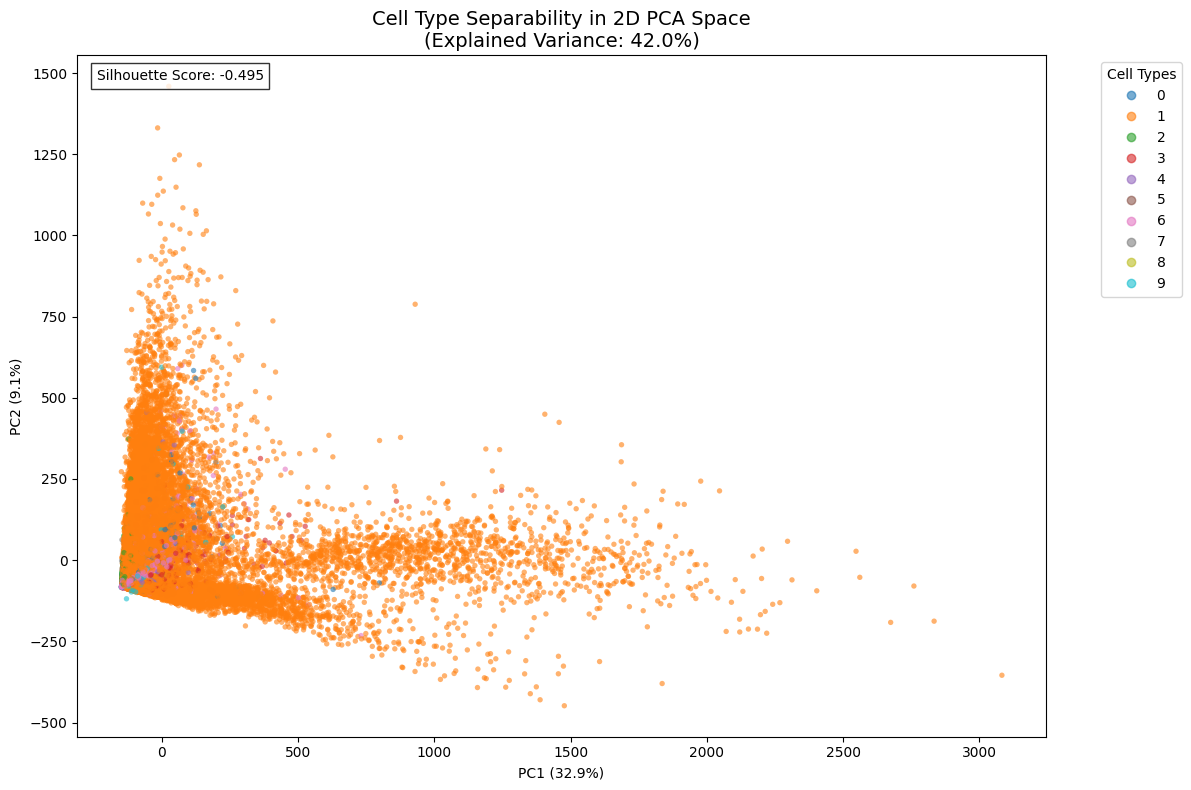


=== PCA Analysis Results ===
Explained Variance Ratio (2D): [0.32873567 0.09094934]
Silhouette Score: -0.495

Interpretation Guide:
- Silhouette Score > 0.5: Strong clustering
- Score 0.25-0.5: Moderate separation
- Score < 0.25: Weak clustering


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap

# Load and prepare data
train_data = pd.read_csv("train.csv")  # Adjust path as needed
train_data.columns = train_data.columns.str.replace('-', '_')
X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType']

# 1. Compute PCA and metrics
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
silhouette = silhouette_score(X_pca, y_train.astype('category').cat.codes)

# 2. Create visualization in memory
plt.figure(figsize=(12, 8))
cmap = ListedColormap([
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
])

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train.astype('category').cat.codes,
    cmap=cmap,
    alpha=0.6,
    s=15,
    edgecolor='none'
)

plt.title('Cell Type Separability in 2D PCA Space\n(Explained Variance: {:.1f}%)'.format(
    sum(pca.explained_variance_ratio_) * 100),
    fontsize=14
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(*scatter.legend_elements(), title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add silhouette score annotation
plt.text(0.02, 0.98, f'Silhouette Score: {silhouette:.3f}',
         transform=plt.gca().transAxes, ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()  # Display plot without saving

# 3. Print quantitative results
print("\n=== PCA Analysis Results ===")
print(f"Explained Variance Ratio (2D): {pca.explained_variance_ratio_}")
print(f"Silhouette Score: {silhouette:.3f}")
print("\nInterpretation Guide:")
print("- Silhouette Score > 0.5: Strong clustering")
print("- Score 0.25-0.5: Moderate separation") 
print("- Score < 0.25: Weak clustering")

# Optional: 3D visualization
show_3d = False  # Set to True if needed
if show_3d:
    from mpl_toolkits.mplot3d import Axes3D
    pca3d = PCA(n_components=3)
    X_pca3 = pca3d.fit_transform(X_train)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
               c=y_train.astype('category').cat.codes,
               cmap=cmap, alpha=0.6, s=10)
    plt.show()

In [ ]:
# ^^^ This 2D PCA plot visualizes the distribution of cell types in reduced feature space.
# The explained variance (42%) suggests moderate retention of original structure.
# The silhouette score (-0.495) indicates poor cluster separability among cell types.

Loading RDS files...


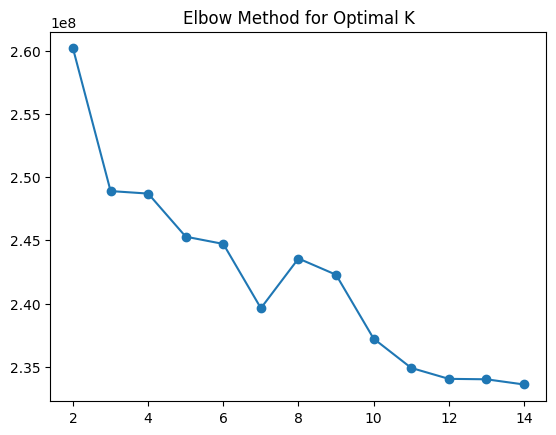

Predictions saved to kmeans_predictions.csv


In [12]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pyreadr  # For reading RDS files

# 1. Load Data
print("Loading RDS files...")
train_data = pyreadr.read_r("train.rds")[None]
test_data = pyreadr.read_r("test.rds")[None]  # This was missing

# Clean column names
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
test_data.columns = test_data.columns.str.replace('[- ]', '_', regex=True)

# 2. Prepare Data
X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType']
X_test = test_data.drop(['SampleID'], axis=1)  # Now test_data exists

# 3. Standardize Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Determine Optimal Clusters
inertia = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 15), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.show()

# 5. Train K-means (using optimal K)
optimal_k = 10  # Change based on elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
train_clusters = kmeans.fit_predict(X_train_scaled)

# 6. Map Clusters to Cell Types
cluster_to_type = {}
for cluster in range(optimal_k):
    cluster_labels = y_train[train_clusters == cluster]
    if len(cluster_labels) > 0:
        cluster_to_type[cluster] = cluster_labels.mode()[0]
    else:
        cluster_to_type[cluster] = f"Unknown_{cluster}"

# 7. Predict Test Set
test_clusters = kmeans.predict(X_test_scaled)
test_pred = [cluster_to_type[c] for c in test_clusters]

# 8. Save Results
results = pd.DataFrame({
    'SampleID': test_data['SampleID'],
    'Cluster': test_clusters,
    'Predicted_CellType': test_pred
})
results.to_csv('kmeans_predictions.csv', index=False)

print("Predictions saved to kmeans_predictions.csv")

In [ ]:
# ^^^^ This elbow plot visualizes within-cluster inertia for different k values (2–14).
# A visible "elbow" indicates the optimal number of clusters for KMeans (suggests k ≈ 10 here).
# The goal is to balance cluster compactness with model simplicity.

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report
from collections import defaultdict
import pyreadr  # For reading RDS files

# 1. Load and prepare data
print("Loading data...")
train_data = pyreadr.read_r("train.rds")[None]
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)

X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType']

# 2. Preprocess data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 3. Dimensionality reduction
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# 4. Cluster with K-means
print("Running K-means clustering...")
kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

# 5. Map clusters to cell types
cluster_to_type = defaultdict(list)
for cluster, true_label in zip(cluster_labels, y_train):
    cluster_to_type[cluster].append(true_label)

cluster_mapping = {}
for cluster in cluster_to_type:
    cluster_mapping[cluster] = max(set(cluster_to_type[cluster]), 
                               key=cluster_to_type[cluster].count)

# 6. Generate predictions
y_pred = np.array([cluster_mapping[cluster] for cluster in cluster_labels])

# 7. Evaluate performance
print("\n=== Performance Metrics ===")
print(f"Accuracy: {accuracy_score(y_train, y_pred):.3f}")
print(f"Weighted F1: {f1_score(y_train, y_pred, average='weighted'):.3f}")
print("\n=== Classification Report ===")
print(classification_report(y_train, y_pred))

# 8. Show top markers per cluster
print("\n=== Top Markers per Cluster ===")
for cluster in cluster_mapping:
    print(f"\nCluster {cluster} (Predicted as: {cluster_mapping[cluster]}):")
    cluster_data = X_train.iloc[cluster_labels == cluster]
    print(cluster_data.mean().sort_values(ascending=False).head(3))

Loading data...
Running K-means clustering...

=== Performance Metrics ===
Accuracy: 0.889
Weighted F1: 0.857

=== Classification Report ===
              precision    recall  f1-score   support

         1.0       1.00      0.54      0.70       449
         2.0       0.89      1.00      0.94     24766
         3.0       0.00      0.00      0.00       830
         4.0       0.00      0.00      0.00       389
         5.0       0.00      0.00      0.00        65
         6.0       0.00      0.00      0.00        21
         7.0       0.84      0.68      0.75      3700
         8.0       0.00      0.00      0.00       559
         9.0       0.00      0.00      0.00        66
        10.0       1.00      0.54      0.70       166

    accuracy                           0.89     31011
   macro avg       0.37      0.27      0.31     31011
weighted avg       0.83      0.89      0.86     31011


=== Top Markers per Cluster ===

Cluster 2 (Predicted as: 2.0):


C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Harshit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

APOC1    28.577273
CCL2     28.020403
CD74     24.259345
dtype: float64

Cluster 3 (Predicted as: 2.0):
APOC1      296.785047
HLA_DRA    190.870258
MT_CO3     179.742716
dtype: float64

Cluster 5 (Predicted as: 1.0):
S100A6     278.811111
SLPI       271.916667
SCGB3A1    181.011111
dtype: float64

Cluster 0 (Predicted as: 7.0):
HLA_A     24.632335
GNLY      22.676647
IFITM1    21.669062
dtype: float64

Cluster 9 (Predicted as: 7.0):
GAPDH     119.661638
MT_CO3     97.592672
ACTG1      78.637931
dtype: float64

Cluster 7 (Predicted as: 2.0):
CCL2      168.0715
CD74       79.3630
CXCL10     76.1255
dtype: float64

Cluster 6 (Predicted as: 2.0):
CD74        669.764368
APOC1       585.268473
HLA_DRB1    302.318555
dtype: float64

Cluster 1 (Predicted as: 1.0):
MT_ND3      202.393443
S100A6      113.754098
HSP90AA1    110.295082
dtype: float64

Cluster 4 (Predicted as: 1.0):
MT_ND3    170.0
S100A6    151.0
IFI27     114.0
dtype: float64

Cluster 8 (Predicted as: 10.0):
IGKV3_20    600.67415

Loading data...


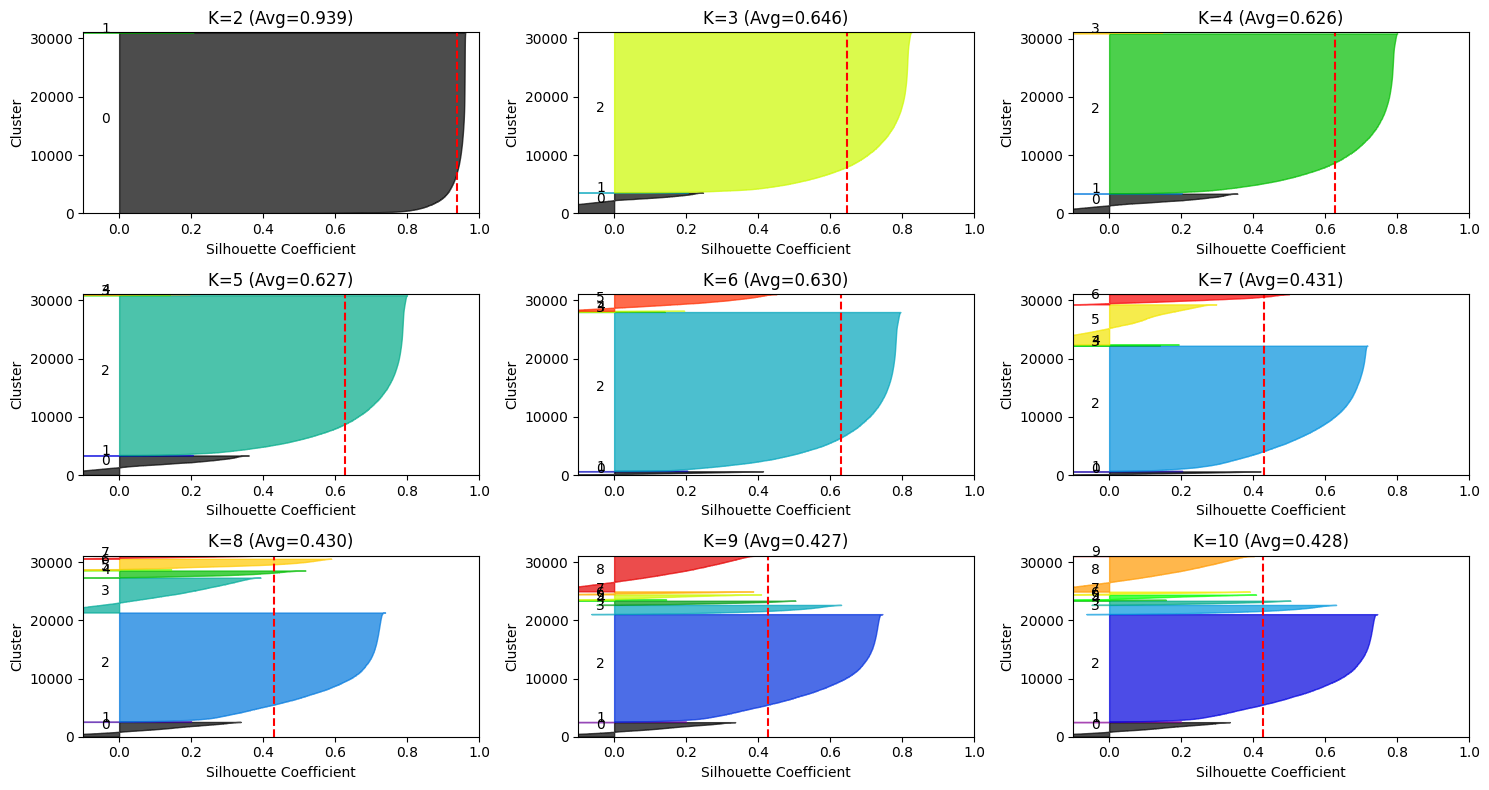

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pyreadr

# 1. Load and prepare data
print("Loading data...")
train_data = pyreadr.read_r("train.rds")[None]
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType']

# 2. Preprocess data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# 3. Set range of clusters to test
cluster_range = range(2, 11)  # Testing from 2 to 10 clusters
plt.figure(figsize=(15, 8))

for i, k in enumerate(cluster_range):
    # Create subplot for each k
    plt.subplot(3, 3, i+1)
    
    # Run K-means
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    
    # Calculate silhouette scores
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)
    
    # Plot silhouette graph
    y_lower = 10
    for j in range(k):
        # Aggregate silhouette scores for cluster j
        jth_cluster_values = sample_silhouette_values[cluster_labels == j]
        jth_cluster_values.sort()
        
        y_upper = y_lower + jth_cluster_values.shape[0]
        
        color = plt.cm.nipy_spectral(float(j) / k)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                         0, jth_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Label clusters
        plt.text(-0.05, y_lower + 0.5 * jth_cluster_values.shape[0], str(j))
        y_lower = y_upper + 10
    
    plt.title(f"K={k} (Avg={silhouette_avg:.3f})")
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.xlim([-0.1, 1])
    plt.ylim([0, len(X_pca) + (k + 1) * 10])

plt.tight_layout()
plt.show()

In [ ]:
# This code computes and visualizes silhouette scores for KMeans clustering with k = 2 to 10.
# Each subplot shows how well-separated clusters are at each k, with higher and tighter silhouette values being better.
# The red dashed line shows the average silhouette score, helping identify the most appropriate k for clustering.


# Although k=2 has the highest silhouette score, it underrepresents the diversity of cell types.  
# Since the goal is prediction, using k=10 aligns better with the actual number of cell type labels.  
# This allows for more accurate mapping of clusters to known cell types during inference.

Loading data...


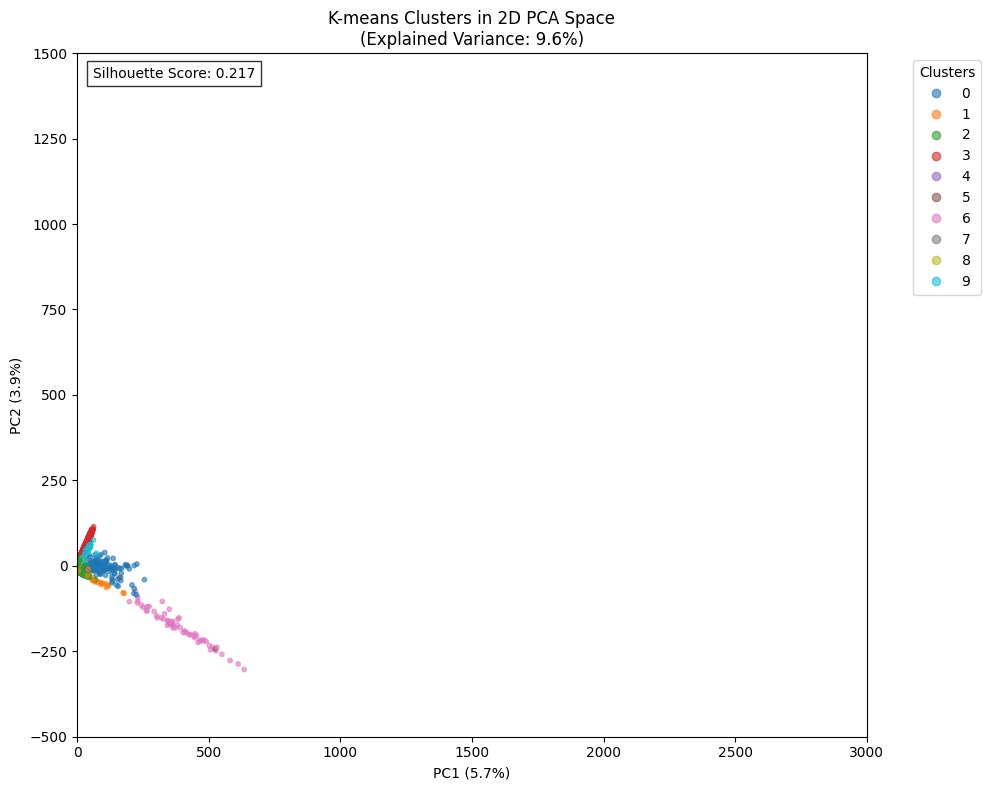

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pyreadr  # For reading RDS files

# 1. Load and prepare data
print("Loading data...")
train_data = pyreadr.read_r("train.rds")[None]
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)

X_train = train_data.drop(['SampleID', 'CellType'], axis=1)
y_train = train_data['CellType']

# 2. Preprocess data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)  # Now X_scaled is defined

# 3. Run PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Cluster with K-means
kmeans = KMeans(n_clusters=10, random_state=42)  # Using 7 clusters
cluster_labels = kmeans.fit_predict(X_scaled)  # Cluster on all features

# 5. Create the plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            c=cluster_labels, 
            cmap='tab10', 
            s=10, 
            alpha=0.6)

# Formatting to match your example
plt.title(f"K-means Clusters in 2D PCA Space\n(Explained Variance: {100*pca.explained_variance_ratio_.sum():.1f}%)")
plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")

# Add legend
plt.legend(*scatter.legend_elements(),
           title="Clusters",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

# Add silhouette score
silhouette = silhouette_score(X_scaled, cluster_labels)  # Using scaled data
plt.text(0.02, 0.98, f"Silhouette Score: {silhouette:.3f}",
         transform=plt.gca().transAxes,
         ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.8))

# Set axis limits to match your example
plt.xlim([0, 3000])
plt.ylim([-500, 1500])

plt.tight_layout()
plt.show()

In [ ]:
# This 2D PCA plot visualizes KMeans clusters (k=10) projected from high-dimensional gene data.  
# The low silhouette score (0.217) indicates weak cluster separation, suggesting significant overlap.  
# The PCA explains only 9.6% of the variance, so cluster structure may be clearer in higher dimensions.

In [7]:
import pyreadr
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier

# 1. Load and prepare data
train_data = pyreadr.read_r("train.rds")[None]
train_data.columns = train_data.columns.str.replace('[- ]', '_', regex=True)
X = train_data.drop(columns=['SampleID', 'CellType'])
y = train_data['CellType']

# 2. Encode labels and standardize features
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train/Validation split (for model evaluation)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 4. Train XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax', 
    num_class=len(label_encoder.classes_), 
    eval_metric='mlogloss', 
)
xgb_model.fit(X_train, y_train)

# 5. Predict on validation set
val_preds = xgb_model.predict(X_val)

# 6. Evaluation
print("\n=== XGBoost Evaluation Metrics ===")
print(f"Accuracy: {accuracy_score(y_val, val_preds):.3f}")
print(f"Macro F1 Score: {f1_score(y_val, val_preds, average='macro'):.3f}")
print(f"Weighted F1 Score: {f1_score(y_val, val_preds, average='weighted'):.3f}")
print("\nClassification Report:\n", classification_report(y_val, val_preds, target_names=label_encoder.classes_.astype(str)))



=== XGBoost Evaluation Metrics ===
Accuracy: 0.975
Macro F1 Score: 0.899
Weighted F1 Score: 0.974

Classification Report:
               precision    recall  f1-score   support

         1.0       1.00      0.93      0.97        90
         2.0       0.98      0.99      0.99      4954
         3.0       0.89      0.72      0.80       166
         4.0       0.85      0.56      0.68        78
         5.0       1.00      0.69      0.82        13
         6.0       1.00      1.00      1.00         4
         7.0       0.97      0.98      0.97       740
         8.0       0.90      0.90      0.90       112
         9.0       1.00      0.92      0.96        13
        10.0       0.94      0.88      0.91        33

    accuracy                           0.97      6203
   macro avg       0.95      0.86      0.90      6203
weighted avg       0.97      0.97      0.97      6203



In [ ]:
# The 2D PCA visualization is used only for interpretability and visualization of sample separability.  
# Despite low explained variance (~9.6%), it can still illustrate broad structure or class overlap.  
# All model training and prediction should be done on the full high-dimensional feature set.

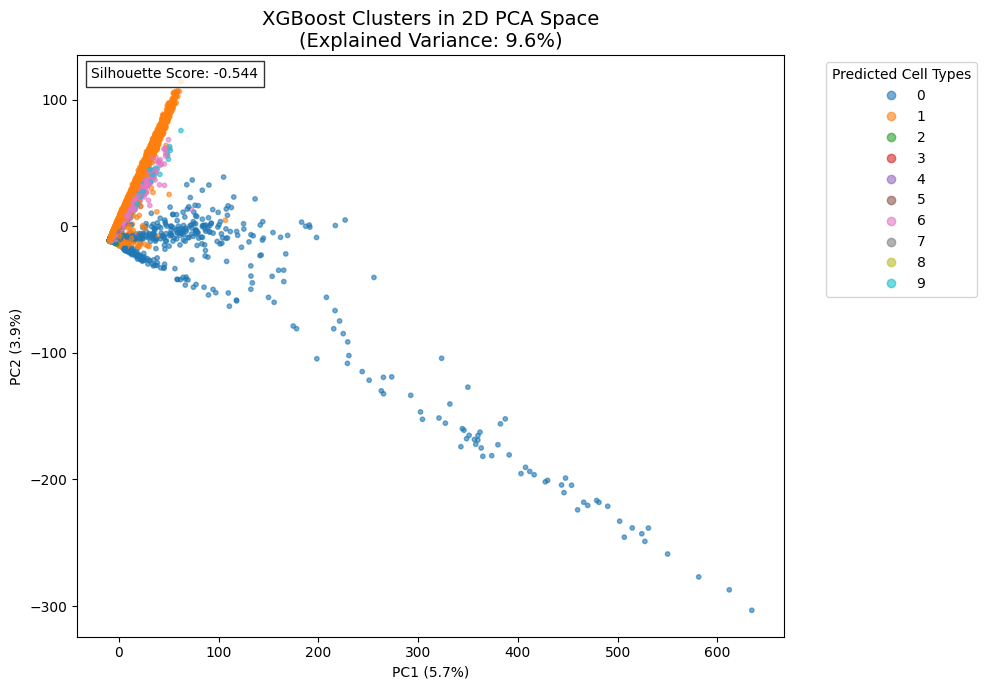

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap

# 1. Project data to 2D PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Predict with trained XGBoost model
final_preds = xgb_model.predict(X_scaled)  # or use X_val if you prefer validation only

# 3. Calculate silhouette score for predictions
sil_score = silhouette_score(X_pca, final_preds)

# 4. Plot
plt.figure(figsize=(10, 7))
cmap = ListedColormap(plt.cm.tab10.colors[:len(np.unique(final_preds))])
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_preds, cmap=cmap, s=10, alpha=0.6)
plt.title(f'XGBoost Clusters in 2D PCA Space\n(Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(*scatter.legend_elements(), title="Predicted Cell Types", bbox_to_anchor=(1.05, 1), loc='upper left')

# Silhouette score annotation
plt.text(0.02, 0.98, f"Silhouette Score: {sil_score:.3f}",
         transform=plt.gca().transAxes, ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()
